# MCAR, MAR, and MNAR:  Practice
This notebook creates random data with NumPy, adds three types of missing values, checks the patterns, and imputes the missing values.
**Note:** In real datasets, MCAR/MAR/MNAR cannot be proven from observed data alone. Here, we know the rules because we created the missingness ourselves.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Generate random student data

In [2]:
n = 100

students = pd.DataFrame({
    "Student_ID": np.arange(1, n + 1),
    "Age": np.random.randint(18, 25, n),
    "Study_Hours": np.round(np.random.uniform(1, 8, n), 2),
    "Exam_Marks": np.round(np.random.normal(65, 12, n).clip(0, 100), 2),
    "Income": np.round(np.random.normal(35000, 10000, n).clip(15000, 100000), 2)
})

students.head()

,Student_ID,Age,Study_Hours,Exam_Marks,Income
0,1,24,1.62,78.71,30146.36
1,2,21,2.37,74.02,35818.74
2,3,22,1.32,74.49,58146.59
3,4,24,3.28,54.09,16327.35
4,5,20,3.72,81.83,41862.60


## 3. Check the original data

In [3]:
print("Shape:", students.shape)
print("\nMissing values:")
print(students.isna().sum())

Shape: (100, 5)

Missing values:
Student_ID     0
Age            0
Study_Hours    0
Exam_Marks     0
Income         0
dtype: int64


# MCAR
## 4. Create MCAR missing values
MCAR means values are missing completely at random. We randomly remove 15% of the exam marks.

In [4]:
mcar_data = students.copy()

mcar_indexes = np.random.choice(
    mcar_data.index,
    size=int(0.15 * n),
    replace=False
)
print(mcar_indexes)
mcar_data.loc[mcar_indexes, "Exam_Marks"] = np.nan

print(mcar_data.isna().sum())

[20 55 66 58 40 80 54 89 43 10 74 31 59 14 81]
Student_ID      0
Age             0
Study_Hours     0
Exam_Marks     15
Income          0
dtype: int64


## 5. Inspect MCAR pattern

In [5]:
mcar_data["Marks_Missing"] = mcar_data["Exam_Marks"].isna()

mcar_comparison = mcar_data.groupby("Marks_Missing")[
    ["Age", "Study_Hours", "Income"]
].mean()

mcar_comparison.index = ["Observed", "Missing"]
mcar_comparison

,Age,Study_Hours,Income
Observed,21.188235,4.265647,35183.895882
Missing,21.333333,4.222000,36749.724000


**Justification:** The missing rows were selected randomly. The comparison is only a check; it cannot prove MCAR in a real dataset.

## 6. Impute MCAR using the overall mean

In [6]:
mcar_imputed = mcar_data.copy()

mean_marks = mcar_imputed["Exam_Marks"].mean()
mcar_imputed["Exam_Marks"] = mcar_imputed["Exam_Marks"].fillna(mean_marks)

print("Mean used:", round(mean_marks, 2))
print("Remaining missing values:", mcar_imputed["Exam_Marks"].isna().sum())

Mean used: 66.45
Remaining missing values: 0


# MAR
## 7. Create MAR missing values
MAR means missingness depends on another observed variable. Here, students with study hours below 4 have a higher chance of missing exam marks.

In [17]:
mar_data = students.copy()

missing_probability = np.where(
    mar_data["Study_Hours"] < 4,
    0.35,
    0.05
)
print(mar_data["Study_Hours"])
print(missing_probability)
mar_mask = np.random.random(n) < missing_probability
mar_data.loc[mar_mask, "Exam_Marks"] = np.nan

print(mar_data.isna().sum())

0     1.62
1     2.37
2     1.32
3     3.28
4     3.72
      ... 
95    2.68
96    2.01
97    4.43
98    7.90
99    2.69
Name: Study_Hours, Length: 100, dtype: float64
[0.35 0.35 0.35 0.35 0.35 0.35 0.05 0.35 0.35 0.05 0.35 0.05 0.35 0.05
 0.05 0.35 0.35 0.05 0.05 0.05 0.05 0.35 0.35 0.35 0.05 0.05 0.35 0.35
 0.35 0.35 0.05 0.05 0.05 0.05 0.35 0.05 0.05 0.05 0.05 0.05 0.05 0.35
 0.35 0.35 0.35 0.05 0.35 0.05 0.05 0.35 0.35 0.05 0.35 0.35 0.35 0.35
 0.05 0.05 0.05 0.05 0.05 0.35 0.05 0.05 0.05 0.05 0.35 0.35 0.35 0.35
 0.05 0.05 0.35 0.05 0.35 0.35 0.35 0.35 0.05 0.35 0.05 0.05 0.35 0.05
 0.05 0.35 0.05 0.35 0.35 0.35 0.05 0.05 0.35 0.35 0.05 0.35 0.35 0.05
 0.05 0.35]
Student_ID      0
Age             0
Study_Hours     0
Exam_Marks     14
Income          0
dtype: int64


## 8. Inspect MAR pattern

In [8]:
mar_data["Marks_Missing"] = mar_data["Exam_Marks"].isna()

mar_data["Study_Group"] = np.where(
    mar_data["Study_Hours"] < 4,
    "Low study hours",
    "Higher study hours"
)

missing_rate = mar_data.groupby("Study_Group")["Marks_Missing"].mean() * 100
missing_rate

Study_Group
Higher study hours     8.333333
Low study hours       32.692308
Name: Marks_Missing, dtype: float64

**Justification:** Missingness was created using `Study_Hours`, which is observed. A higher missing rate in the low-study-hours group supports the MAR rule used in this simulation.

## 9. Impute MAR using group-wise mean

In [9]:
mar_imputed = mar_data.copy()

group_means = mar_imputed.groupby("Study_Group")[
    "Exam_Marks"
].transform("mean")

mar_imputed["Exam_Marks"] = mar_imputed["Exam_Marks"].fillna(group_means)

print("Remaining missing values:", mar_imputed["Exam_Marks"].isna().sum())

Remaining missing values: 0


# MNAR
## 10. Create MNAR missing values
MNAR means missingness depends on the value that is missing. Here, students with original exam marks above 75 have a higher chance of hiding their marks.

In [10]:
mnar_data = students.copy()

missing_probability = np.where(
    mnar_data["Exam_Marks"] > 75,
    0.70,
    0.05
)

mnar_mask = np.random.random(n) < missing_probability
mnar_data.loc[mnar_mask, "Exam_Marks"] = np.nan

print(mnar_data.isna().sum())

Student_ID      0
Age             0
Study_Hours     0
Exam_Marks     18
Income          0
dtype: int64


## 11. Inspect MNAR pattern using the original data

In [11]:
mnar_check = students[["Student_ID", "Exam_Marks"]].copy()
mnar_check["Was_Made_Missing"] = mnar_mask

mnar_check.groupby("Was_Made_Missing")["Exam_Marks"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Was_Made_Missing,,,,
False,82,64.014634,45.71,100.00
True,18,76.948333,55.21,91.29


**Justification:** We compare with the original complete data because this is a simulation. In real life, the original missing values are not available, which makes MNAR difficult to identify.

## 12. Impute MNAR using the median (basic demonstration)

In [12]:
mnar_imputed = mnar_data.copy()

median_marks = mnar_imputed["Exam_Marks"].median()
mnar_imputed["Exam_Marks"] = mnar_imputed["Exam_Marks"].fillna(median_marks)

print("Median used:", round(median_marks, 2))
print("Remaining missing values:", mnar_imputed["Exam_Marks"].isna().sum())

Median used: 66.01
Remaining missing values: 0


## 13. Visualize missingness

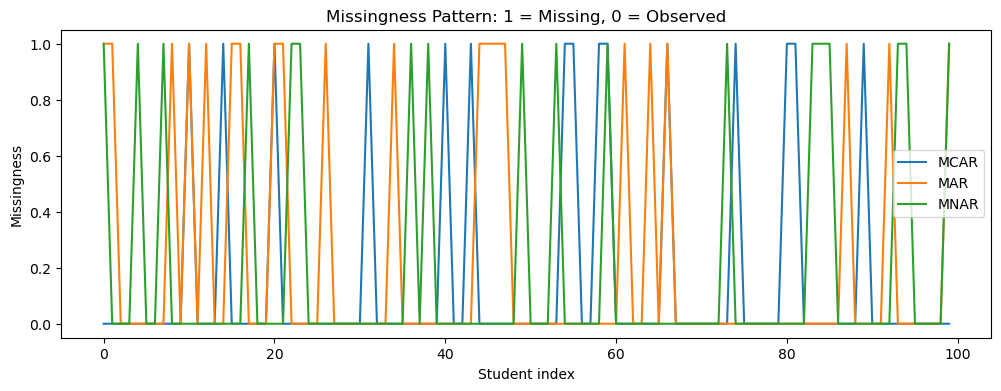

In [13]:
missing_patterns = pd.DataFrame({
    "MCAR": students.index.isin(mcar_indexes),
    "MAR": mar_mask,
    "MNAR": mnar_mask
}).astype(int)

missing_patterns.plot(
    figsize=(12, 4),
    title="Missingness Pattern: 1 = Missing, 0 = Observed"
)

plt.xlabel("Student index")
plt.ylabel("Missingness")
plt.show()

## 14. Final comparison

| Type | Missingness rule | Imputation used |
|---|---|---|
| MCAR | Random row selection | Overall mean |
| MAR | Depends on observed study hours | Group-wise mean |
| MNAR | Depends on original exam marks | Median |

**Conclusion:** Mean imputation is simple for MCAR. Group-wise imputation uses an observed predictor for MAR. MNAR needs extra assumptions or sensitivity analysis because the missing value itself affects missingness.

## 15. Final verification

In [14]:
print("MCAR remaining missing:", mcar_imputed["Exam_Marks"].isna().sum())
print("MAR remaining missing:", mar_imputed["Exam_Marks"].isna().sum())
print("MNAR remaining missing:", mnar_imputed["Exam_Marks"].isna().sum())

MCAR remaining missing: 0
MAR remaining missing: 0
MNAR remaining missing: 0
